In [5]:
import sys
import os
from pathlib import Path

import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath("../..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"Project root: {project_root}")

from src.models import (
    gqnn,
    gqnn_shape,
    draw_circuit,
)

from src.datagen import (
    mackey_glass,
    create_io_pairs,
)

from projects.expressivity_krylov.krylov.metrics import (
    krylov_expressivity
)

from projects.expressivity_krylov.krylov.plotting import (
    plot_krylov_distribution,
    plot_lanczos_coefficients,
)

Project root: /home/miron/QML/AIntern/qtsa_expressivity


ImportError: cannot import name 'krylov_expressivity' from 'projects.expressivity_krylov.krylov.metrics' (/home/miron/QML/AIntern/qtsa_expressivity/projects/expressivity_krylov/krylov/metrics.py)

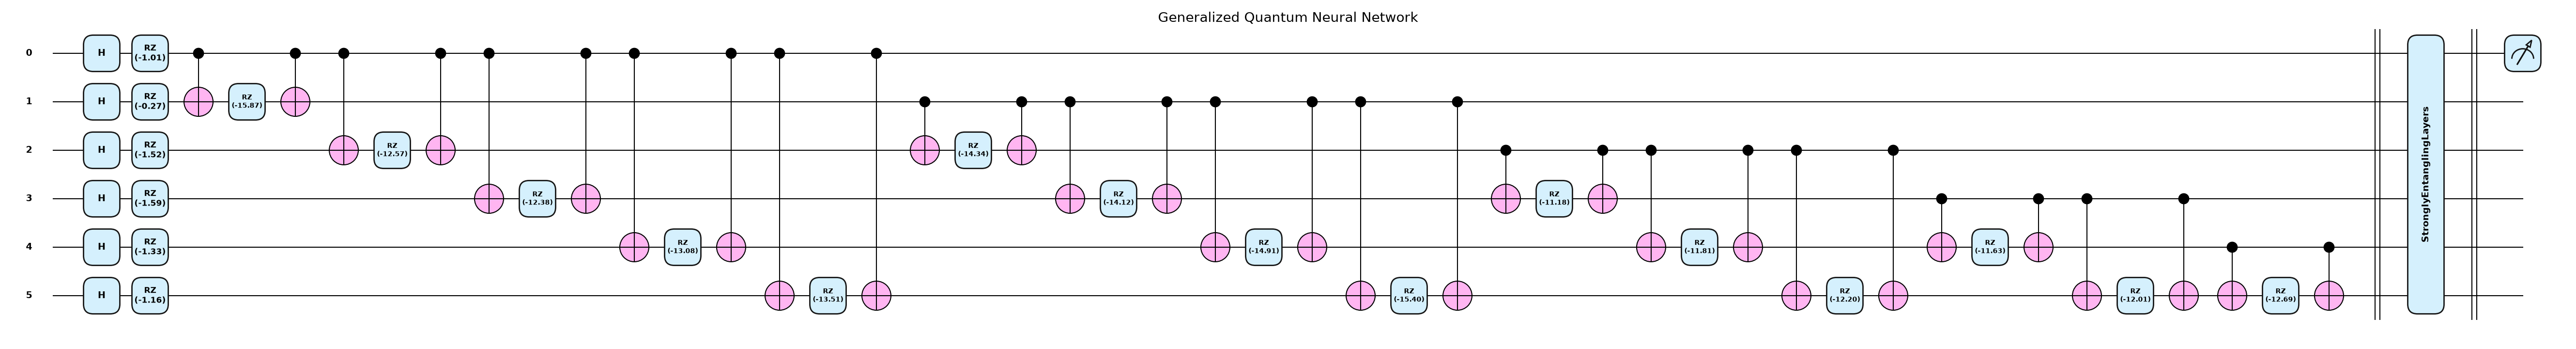

In [2]:
n_qubits = 6
n_layers = 4
feature_map = "zzfm"

dev = qml.device("default.qubit", wires=n_qubits)

model = gqnn(
    n_layers=n_layers,
    n_qubits=n_qubits,
    dev=dev,
    fm_style=feature_map,
)

weight_shape = gqnn_shape(n_layers, n_qubits)
weights = np.random.normal(scale=0.1, size=weight_shape)

# Random input
x = np.random.rand(n_qubits)

draw_circuit(
    model,
    title="Generalized Quantum Neural Network",
)(x, weights)

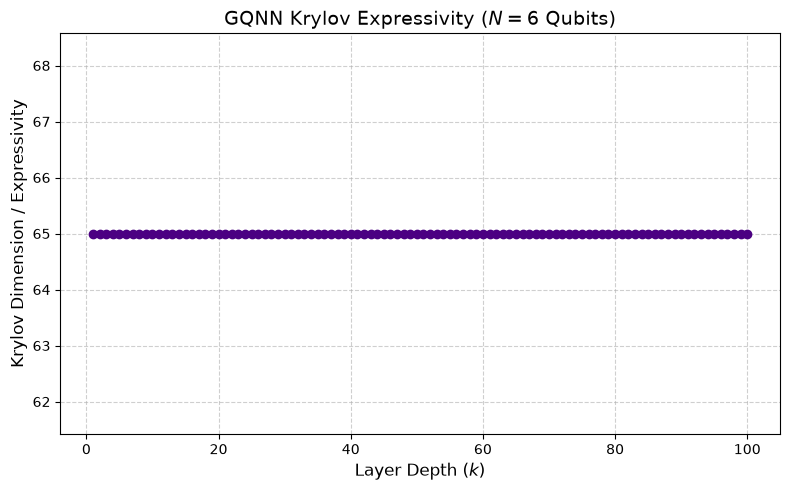

In [9]:
import pennylane as qml
from pennylane import numpy as np

from projects.expressivity_krylov.krylov.basis import get_subnetwork_unitary
from projects.expressivity_krylov.krylov.metrics import compute_krylov_expressivity
from projects.expressivity_krylov.krylov.plotting import plot_krylov_expressivity

# Setup dimensions
n_qubits = 6
n_layers = 20
feature_map = "zzfm"

weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
weights = np.random.normal(scale=0.1, size=weight_shape)
x = np.random.rand(n_qubits)

# Single qubit initial observable Z_0 in full Hilbert space
Z0 = np.kron(np.array([[1, 0], [0, -1]]), np.eye(2**(n_qubits - 1)))

# Compute Krylov Expressivity for sub-networks 1 <= k <= N
results = compute_krylov_expressivity(
    n_layers=n_layers, 
    n_qubits=n_qubits, 
    weights=weights, 
    inputs=x, 
    O_0=Z0, 
    fm_style=feature_map
)

# Plot expressivity growth across layer depths
plot_krylov_expressivity(results, title="GQNN Krylov Expressivity ($N=6$ Qubits)")